# Lab 0: Welcome to the Qiskit Global Summer School 2026 

This is Lab 0, your warm-up notebook to get you ready for the main event. In this lab, you will:

- Upgrade your Python packages
- Complete simple coding exercises with Sampler and Estimator
- Build a special multi-qubit quantum circuit and explore its statevector
- *(Optional)* Build a quantum circuit in C using the Qiskit C API

Excited? There's plenty more ahead!


This lab runs on macOS, Linux, and cloud platforms like [qBraid](https://qbraid.com/) and [Google Colab](https://colab.research.google.com/). If you're on Windows, we recommend using a cloud platform for the best experience, especially for the upcoming labs where some packages work best in Linux-based environments.

Here's a quick summary:

| Your OS | How to run this lab |
|---|---|
| macOS / Linux | Run locally — the notebook handles setup for you. |
| Windows | Chapters 1–2 run locally with Python and venv. For the optional chapter 3, open this notebook on [qBraid](https://qbraid.com/) or [Google Colab](https://colab.research.google.com/). |

<br>


## Installation

Run this cell first to check your Python version.

In [1]:
import sys

recommended = (3, 10)
current = sys.version_info[:2]

if current < recommended:
    print(f"You are using Python {current[0]}.{current[1]}. Python {recommended[0]}.{recommended[1]} or later is recommended.")
else:
    print(f"Python {current[0]}.{current[1]} — looks good!")


Python 3.13 — looks good!


Next, run the cell below to install and upgrade the required packages. If the upgrade process causes dependency conflicts with packages already installed in your local environment, __create a new Python environment__ (Python 3.12 recommended) and continue the challenge there. 

For guidance on setting up a clean environment and installing Qiskit, refer to the IBM Quantum documentation: https://quantum.cloud.ibm.com/docs/guides/install-qiskit

In [2]:
# Install required packages.
# Uncomment the lines below the first time you run this notebook to install dependencies,
# then re-comment them on subsequent runs.


%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib
%pip install --upgrade qc-grader

  Using cached qiskit-2.5.0-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (14 kB)
  Using cached qiskit_aer-0.17.2-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
  Using cached qiskit_ibm_runtime-0.47.0-py3-none-any.whl.metadata (23 kB)
  Using cached numpy-2.5.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached rustworkx-0.18.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (10 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached stevedore-5.9.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached requests_ntlm-1.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached ibm_platform_services-0.76.0-py3-none-any.whl.metadata (9.3 kB)
  Using cac

Once you have installed and upgraded the libraries, please restart the Python kernel and rerun the notebook starting from the Import Libraries cell below.

In [10]:
import os
import platform
import shutil
import subprocess
import sys

import qc_grader
import qiskit

from qc_grader.challenges.qgss_2026 import check_progress
from qc_grader.challenges.qgss_2026.lab0 import (
    grade_lab0_ex1,
    grade_lab0_ex2,
    grade_lab0_ex3,
    grade_lab0_ex4,
)


from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt

print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")



Qiskit version: 2.5.0
Grader version: 2026.7.2


# Chapter 1 — Your first quantum program with Qiskit patterns

## 1.1 IBM Quantum Account

First things first! To participate in the main event, you'll need an active IBM Quantum account.

If you've already saved your account credentials with `QiskitRuntimeService`, you can just run the cell below and your backend list will appear. If you're a new user, or it's been a while since you last set things up, follow these steps to save your account:

1. Go to [quantum.cloud.ibm.com](https://quantum.cloud.ibm.com/) and sign in (or create an account).
2. Copy your API key by clicking `Create +` or `View all` on the dashboard.
3. Copy your instance CRN from the Instances tab.
4. Replace the placeholders in the cell below with your API key and Instance CRN, then run it.

Once that's done, run the grader cell to confirm your credentials are set up correctly.

In [ ]:
# Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.

#token = ""
#instance = ""  # looks like "crn:v1:bluemix:public:quantum-computing:..."

#QiskitRuntimeService.save_account(
#    token=token,
#    instance=instance,
#    overwrite=True,
#    set_as_default=True,
#)

# Verify
service = QiskitRuntimeService()
backends = service.backends()
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")


Account OK. 3 backend(s) available:
  ibm_fez (156 qubits)
  ibm_marrakesh (156 qubits)
  ibm_kingston (156 qubits)


<div class="alert alert-block alert-success">
  <b>Exercise 1: Verify your IBM Quantum account</b>

  Have you set your API key and CRN and checked the available backends?
  Run the Exercise 1 cell below to make sure the grader works properly.
  You don’t need to enter anything!

  If your account is configured correctly, you will see a success message.
</div>


In [4]:
grade_lab0_ex1()

Grading your answer. Please wait...

🎉 Your IBM Quantum account is properly configured!
You have successfully connected to the grading server.
You're all set to continue with the rest of the lab.
You scored 1 on this exercise.


## 1.2 Quantum Computing with Gates

IBM quantum computers are gate-based. We build quantum algorithms by composing quantum gates, much like classical computers use AND, OR, and NOT gates to process bits. A key difference is that quantum gates work on qubits, the quantum counterpart of classical bits. Classical bits are strictly 0 or 1, but qubits can exhibit three quantum mechanical phenomena: superposition (a qubit exists in a linear combination of 0 and 1 until measured), entanglement (two or more qubits share a joint quantum state that cannot be described by the individual qubits independently), and interference (quantum amplitudes can add constructively or destructively, allowing algorithms to suppress wrong answers and reinforce correct ones). These three phenomena are what make quantum computing different from classical computing.

### Superposition and the Hadamard Gate

The [Hadamard gate (H)](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate) takes a qubit in a definite state ($|0\rangle$ or $|1\rangle$) and puts it into an equal superposition of both:

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad H|0\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)$$

When you measure this state, you get 0 or 1 with equal probability (50% each). The $\frac{1}{\sqrt{2}}$ coefficients are probability amplitudes, and the measurement probability of each outcome is the square of its amplitude.

Complete the cell below to build your first 1-qubit circuit with a Hadamard gate.

<br>

<div class="alert alert-block alert-info">

To learn more about superposition, entanglement, and interference, see the [Basics of quantum information](https://quantum.cloud.ibm.com/learning/courses/basics-of-quantum-information) course.

</div>


<div class="alert alert-block alert-success">
<b>Exercise 2: Build your first quantum circuit</b>

Below is an empty 1-qubit circuit. Add a <b>Hadamard gate</b> on qubit 0 to put it into superposition. This is what gives you the characteristic 50/50 split when we run the Sampler in Section 1.6.

Hint: try our official [QuickStart](https://quantum.cloud.ibm.com/docs/guides/quick-start).

</div>


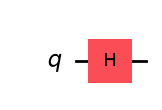

In [11]:

qc = QuantumCircuit(1)

# TODO: Add a Hadamard gate on qubit 0
qc.h(0)

qc.draw("mpl")


## 1.3 What is a Qiskit pattern?

We now have a quantum circuit that prepares the $H|0\rangle$ superposition state. In the next sections, we will run two experiments on this circuit: one to collect measurement counts, and one to compute the expectation value of the Z observable. Both experiments follow the same four-step workflow called a [Qiskit pattern](https://quantum.cloud.ibm.com/docs/guides/intro-to-patterns).

| Step | What you do | In this lab |
|------|------------|-------------|
| 1. Map | Map the problem to quantum circuits and operators. | We build the H circuit and define the Z observable. |
| 2. Optimize | Optimize the circuit for target hardware. | We use `generate_preset_pass_manager` to do this. |
| 3. Execute | Execute on target hardware using primitives. | We run the circuit with both Sampler and Estimator. |
| 4. Post-process | Post-process results. | We plot the measurement histogram and verify that ⟨Z⟩ ≈ 0. |

For the Execute step, Qiskit provides two primitives:

- [SamplerV2](https://quantum.cloud.ibm.com/docs/guides/primitives) samples the output register from quantum circuit execution. We use it to collect measurement counts and verify that 0 and 1 appear with roughly equal frequency.
- [EstimatorV2](https://quantum.cloud.ibm.com/docs/guides/primitives) computes expectation values of observables with respect to states prepared by quantum circuits. We use it to evaluate $\langle Z \rangle$, where $|0\rangle$ has eigenvalue $+1$ and $|1\rangle$ has eigenvalue $-1$, giving $\langle Z \rangle = 0$ for an equal superposition.

The next sections go through each step.

## 1.4 Step 1 — Map

In the Map step, we define the quantum problem as a circuit and an observable.

The circuit is already built: `qc` prepares the $H|0\rangle$ state. Here we define the observable. We use the Z operator (Pauli-Z), which has eigenvalue $+1$ for $|0\rangle$ and $-1$ for $|1\rangle$:

$$Z = |0\rangle\langle 0| - |1\rangle\langle 1|$$

For the $H|0\rangle$ state, both outcomes are equally likely, so the expectation value is:

$$\langle Z \rangle = \frac{1}{2}(+1) + \frac{1}{2}(-1) = 0$$

This is what we will verify with Estimator in the Execute step.

<div class="alert alert-block alert-success">
<b>Exercise 3: Define the observable</b>

In the Map step, you choose what to measure. We want the Pauli-Z operator on qubit 0; its expectation value tells us how biased the qubit is toward |0⟩ vs |1⟩.

Create a single-qubit Z __observable__ using <code>SparsePauliOp</code> with a coefficient $1.0$.

Hint: you can find nice examples in our [SparsePauliOp documentation](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.SparsePauliOp).

</div>


In [12]:
# TODO: Define the observable as the single-qubit Z operator
observable = SparsePauliOp(["Z"], 1.0)

print(f"Observable: {observable}")


Observable: SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


## 1.5 Step 2 — Transpile

Quantum hardware has constraints. Real quantum hardware has a native gate set and a qubit connectivity that are determined by the underlying physical implementation. The `Transpile` step rewrites your abstract circuit into an equivalent circuit that the target backend can actually execute, using its supported gate set and connectivity.

We use `generate_preset_pass_manager` to handle this. In the cells below, we target an ideal simulator, which accepts nearly any gate, so the transpiled circuit will look close to the original. In the optional Section 1.8, we run on real hardware where the transpiler does more work: decomposing gates into the backend's native gate set and optimizing the circuit layout according to the connectivity constraints.

Transpilation applies to both the circuit and the observable. When the transpiler assigns virtual qubits to physical qubits, the observable must reflect that same mapping. We do this with `apply_layout`. Since our circuit has only one qubit, the layout is trivial here, but the same pattern is required for multi-qubit circuits on real hardware.


In [13]:
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# Sampler requires measurements in the circuit
qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm.run(qc_meas)

# Estimator takes the circuit without measurements and evaluates the observable separately
isa_qc = pm.run(qc)

# Apply the same layout to the observable so qubit indices match the transpiled circuit
isa_observable = observable.apply_layout(isa_qc.layout)

print("Transpiled circuit and observable ready.")

Transpiled circuit and observable ready.


## 1.6 Step 3 — Execute

Now we run the transpiled circuit using both primitives. Each answers a different question about the same quantum state.

### Sampler: "What counts do I get?"

The Sampler runs your circuit many times (shots) and counts how often each outcome occurs: how many times do I measure 0, and how many times do I measure 1?

In [14]:
sampler = Sampler(mode=backend)
sampler_result = sampler.run([isa_qc_meas], shots=1000).result()
counts = sampler_result[0].data.meas.get_counts()

print("Sampler counts:", counts)

Sampler counts: {'1': 488, '0': 512}


<div class="alert alert-block alert-success">
<b>Submit & check your Sampler result to complete Exercise 2</b>

The <code>counts</code> you just computed comes from the H circuit you built in Section 1.2. Run the cell below to submit it; the grader checks for the 50/50 split.

</div>


In [15]:
grade_lab0_ex2(counts)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. 512:488 — looks like 50/50 superposition from the Hadamard gate.
You scored 1 on this exercise.


### Estimator: "What value do I get when I observe my quantum circuit?"

Estimator takes the circuit and the observable and returns the expectation value directly, without you having to collect and average counts manually. The circuit does not need measurement gates — Estimator handles the measurement internally.

For the $H|0\rangle$ state, we expect $\langle Z \rangle = 0$.


In [16]:
# Run Estimator — circuit WITHOUT measurements + observable
estimator = Estimator(mode=backend)
estimator_result = estimator.run([(isa_qc, isa_observable)]).result()
exp_val = estimator_result[0].data.evs

print(f"⟨Z⟩ = {exp_val:.4f}")

⟨Z⟩ = 0.0352


<div class="alert alert-block alert-success">
<b>Submit & check your Estimator result to complete Exercise 3</b>

Run the cell below to submit <code>exp_val</code> to the grader. For a perfect H|0⟩ superposition, ⟨Z⟩ should be ≈ 0.

</div>


In [17]:
grade_lab0_ex3(exp_val)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. ⟨Z⟩ = 0.0352 ≈ 0
You scored 1 on this exercise.


## 1.7 Step 4 — Post-process

The Post-process step is where we extract meaning from the raw results. Depending on the problem, this can mean visualizing measurement distributions, computing derived quantities from expectation values, feeding results into a classical optimization loop, or applying error mitigation techniques.

In this lab, we keep it simple. We plot the Sampler counts as a histogram to see how often 0 and 1 were measured, and we plot the Estimator result as a bar chart with an error bar showing the statistical uncertainty on $\langle Z \rangle$. On the simulator we expect equal counts and $\langle Z \rangle \approx 0$. On real hardware, both plots will reflect the effect of shot and device noise.

Sampler counts: {'1': 488, '0': 512}


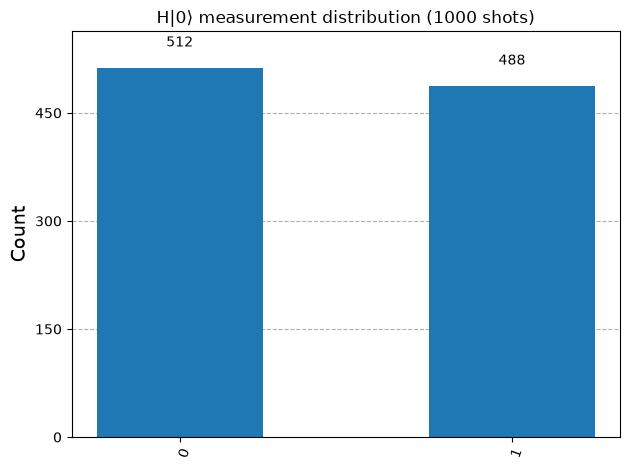


Estimator ⟨Z⟩ = 0.0352 ± 0.0156


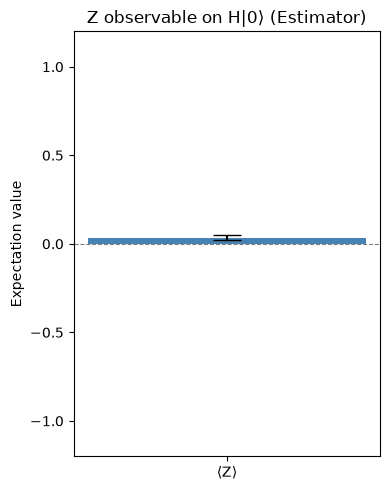

In [18]:

# Sampler results
print(f"Sampler counts: {counts}")
display(plot_histogram(counts, title="H|0⟩ measurement distribution (1000 shots)"))

# Estimator results
ev = estimator_result[0].data.evs.item()
std = estimator_result[0].data.stds.item()
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="steelblue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel("Expectation value")
ax.set_title("Z observable on H|0⟩ (Estimator)")
plt.tight_layout()
plt.show()


## 1.8 (Optional) Run on Real Quantum Hardware

<div class="alert alert-block alert-info">
<b>This section is optional and ungraded.</b> It submits jobs to a real quantum computer and uses your QPU time. You can skip it and continue to Chapter 2.
</div>

So far we used a simulator. Now we run the same circuit on a real IBM quantum processor. The code follows the same Qiskit Patterns workflow. The only change is the backend.

Real quantum hardware operates under physical constraints that simulators do not have. Gates run as microwave pulses on physical qubits, and each operation has a finite fidelity. As a result, the counts will be close to 50/50 but not exact, and $\langle Z \rangle$ will be close to 0 with a measurable uncertainty. Comparing these results with the simulator gives you a concrete sense of where quantum error mitigation becomes useful.

We submit both Sampler and Estimator jobs together using [Batch](https://quantum.cloud.ibm.com/docs/guides/run-jobs-batch). Batch groups multiple jobs into a single backend reservation so they run back-to-back without re-queuing. This job uses approximately 20 seconds of QPU time with `Heron` devices. Queue wait time varies depending on backend load. If the cell times out before printing the job IDs, the following cell shows how to retrieve the results by job ID.

In [22]:
# By default, this section runs on real quantum hardware.
# To save your QPU time for the main event, uncomment the noisy simulator line below
# and replace real_backend with real_backend_sim in the rest of this section.

real_backend = service.least_busy()
real_backend_sim = AerSimulator.from_backend(real_backend)  # noisy simulator

print(f"Running on: {real_backend_sim.name} ({real_backend_sim.num_qubits} qubits)")

# Step 2: Transpile for the target backend
pm_real = generate_preset_pass_manager(optimization_level=1, backend=real_backend_sim)

qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm_real.run(qc_meas)

isa_qc_real = pm_real.run(qc)
isa_obs = observable.apply_layout(isa_qc_real.layout)

# Step 3: Execute — both primitives run in a single Batch to avoid re-queuing
with Batch(backend=real_backend_sim):
    sampler = Sampler()
    sampler.options.environment.job_tags = ["qgss26"]
    sampler_job = sampler.run([isa_qc_meas], shots=1000)

    estimator = Estimator()
    estimator.options.environment.job_tags = ["qgss26"]
    estimator_job = estimator.run([(isa_qc_real, isa_obs)])

sampler_job_id = sampler_job.job_id()
estimator_job_id = estimator_job.job_id()

print(f"Sampler job ID:   {sampler_job_id}")
print(f"Estimator job ID: {estimator_job_id}")


Running on: aer_simulator_from(ibm_kingston) (156 qubits)
Sampler job ID:   cbd8503e-27c5-418c-8545-ed958d6ac0a1
Estimator job ID: 09679041-d4c6-493f-90b3-08baa454d886


In [ ]:
# (Optional) If the cell above timed out before printing the results, copy the
# Sampler/Estimator job IDs from its output into the strings below and run this cell.
# Leave commented otherwise.

# sampler_job_id = "<paste sampler job id>"
# estimator_job_id = "<paste estimator job id>"
# sampler_job = service.job(sampler_job_id)
# estimator_job = service.job(estimator_job_id)


In [23]:
# Step 4: Results
hw_counts = sampler_job.result()[0].data.meas.get_counts()
hw_estimator_result = estimator_job.result()
hw_exp_val = hw_estimator_result[0].data.evs

print(f"Hardware Sampler counts: {hw_counts}")
print(f"Hardware Estimator ⟨Z⟩:  {hw_exp_val:.4f}")

Hardware Sampler counts: {'0': 533, '1': 467}
Hardware Estimator ⟨Z⟩:  -0.0107


Compare the results side by side. The simulator gives a 50/50 split. The hardware results show the effect of noise: small deviations from it.

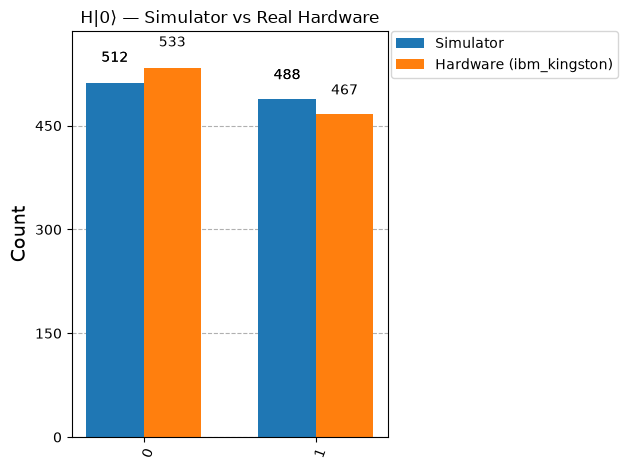


Estimator ⟨Z⟩ = -0.0107 ± 0.0156


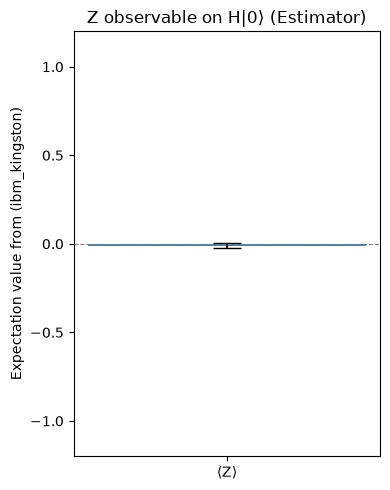

In [24]:
display(plot_histogram(
    [counts, hw_counts],
    legend=["Simulator", f"Hardware ({real_backend.name})"],
    title="H|0⟩ — Simulator vs Real Hardware",
))


# Estimator results
ev = hw_estimator_result[0].data.evs.item()
std = hw_estimator_result[0].data.stds.item()
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="steelblue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel(f"Expectation value from ({real_backend.name})")
ax.set_title("Z observable on H|0⟩ (Estimator)")
plt.tight_layout()
plt.show()


# Chapter 2 — Multi-qubit circuit and visualization

Great work on Chapter 1! You built a single-qubit superposition, ran it through Sampler and Estimator, and saw how the same quantum state looks from two different measurement perspectives — on both a simulator and, if you tried it, real quantum hardware.

Now let's build something more interesting. In this chapter, you will work with 6 qubits to construct a special quantum circuit step by step. At the end, we will look at the statevector it produces and visualize it using [QSphere](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_state_qsphere), a multi-qubit visualization tool that shows the probability and phase of each basis state. You might recognize what the final state looks like.

## 2.1 Build a 6-qubit entangled state

You will use three gates in this exercise:

- [H](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate): puts a qubit into an equal superposition of $|0\rangle$ and $|1\rangle$ (you already know this one).
- [X](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.XGate): flips a qubit from $|0\rangle$ to $|1\rangle$ and vice versa. It is the quantum equivalent of a classical NOT gate.
- [CX](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.CXGate): a two-qubit gate that flips the target qubit if and only if the control qubit is $|1\rangle$. Applying CX to a superposition state creates entanglement between the two qubits.

<div class="alert alert-block alert-info">

If you want to explore these gates further and run them on real hardware, check out <a href="https://quantum.cloud.ibm.com/learning/courses/use-a-qc-today/build-and-run-your-first-quantum-program">Build and run your first quantum program</a>.

</div>


All qubits start in $|0\rangle$. Start with the cell below.


<div class="alert alert-block alert-success">
<b>Exercise 4: Build a 6-qubit entangled state</b>

You will build a 6-qubit circuit. When you visualize it on a QSphere later, you will see something familiar.

Build it in three steps using the cells below:

1. (already given) Create a 6-qubit circuit.
2. Apply <b>H</b> to qubit 0 to put it in superposition, then apply <b>X</b> to qubit 1.
3. Apply a <b>CNOT chain</b> with qubit 0 as control and qubits 1 through 5 as targets to entangle them all.

Hint: you can use a `for` loop to build the CNOT chain.
</div>

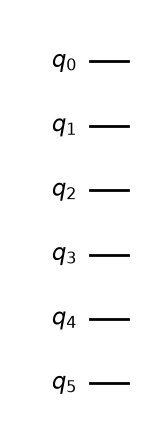

In [19]:
# Step 1: Create a 6-qubit circuit
special_qc = QuantumCircuit(6)
special_qc.draw("mpl")

Next, apply H to qubit 0, putting it into superposition. Then apply X to qubit 1, flipping it from $|0\rangle$ to $|1\rangle$. The circuit now has two qubits prepared in specific states, ready for entanglement in the next step.

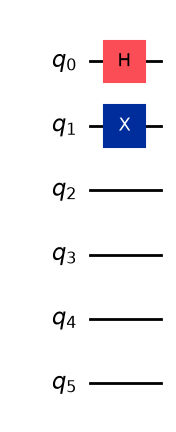

In [28]:
# Step 2: H on qubit 0, X on qubit 1
# TODO: Apply H to qubit 0
special_qc.h(0)

# TODO: Apply X to qubit 1
special_qc.x(1)

special_qc.draw('mpl')


Now we create entanglement using a CNOT chain. Each CNOT gate uses qubit 0 as the control and targets qubits 1 through 5. This links all qubits together: when qubit 0 is in superposition, all other qubits become entangled with it. The circuit diagram shows five CNOT gates connecting qubit 0 to every other qubit.


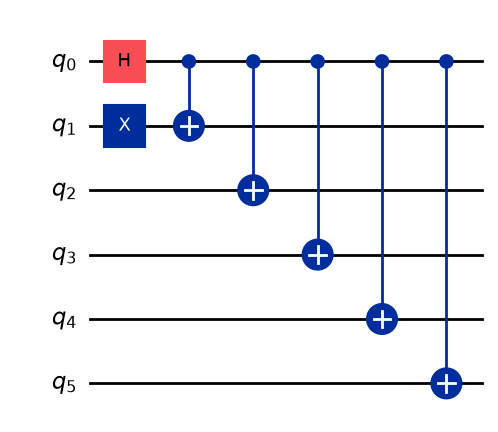

In [29]:
# Step 3: CNOT chain — entangle all qubits with qubit 0
# TODO: Loop over qubits 1 through 5 and apply CNOT with qubit 0 as control
for i in range(1, 6):
    special_qc.cx(0, i)

special_qc.draw('mpl')


## 2.2 Statevector

The statevector is the complete mathematical description of a quantum state. For $n$ qubits, it is a complex vector of $2^n$ amplitudes, one for each possible basis state. The probability of measuring a particular basis state is the square of its amplitude.

For our 6-qubit circuit, the statevector has $2^6 = 64$ entries, covering every basis state from $|000000\rangle$ to $|111111\rangle$. The `Statevector` class computes this from the circuit, and `array_to_latex` prints it in mathematical form.

Most entries will be zero. Only the basis states with non-zero amplitude contribute to the quantum state you built.

In [30]:
sv = Statevector(special_qc)
array_to_latex(sv, max_size=64)

<IPython.core.display.Latex object>

## 2.3 Visualize your quantum state

Reading 64 complex numbers directly is not practical. We need a way to see the structure at a glance.

For a single qubit, the [Bloch sphere](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_bloch_multivector) maps any pure state to a point on the surface of a sphere. But it only works for one qubit at a time, and six separate Bloch spheres cannot show how the qubits are entangled.

The [QSphere](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.visualization.plot_state_qsphere) puts the full multi-qubit state on a single sphere. Each basis state is a point on the sphere, with three properties:

- Latitude is determined by the Hamming weight (the number of 1s in the bitstring). States with no 1s sit at the north pole; states with all 1s sit at the south pole.
- Dot size represents the measurement probability of that basis state. States with zero amplitude do not appear.
- Color represents the quantum phase.

For the state you built, you will see two dots of equal size. Take a look at which basis states they correspond to.

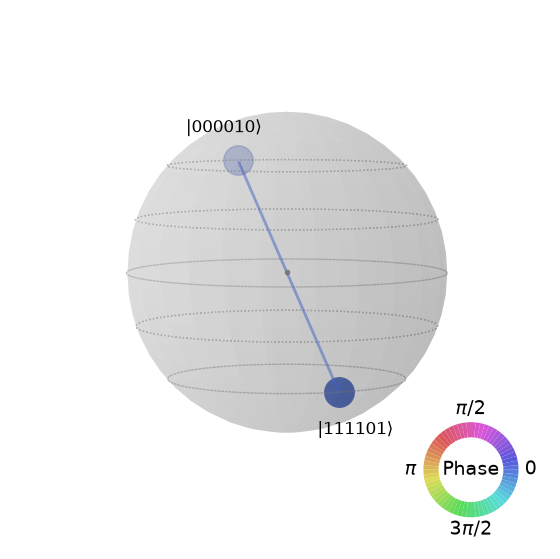

In [31]:
# The QSphere
plot_state_qsphere(sv)

### What the QSphere shows

The QSphere has two dots, one near the top and one near the bottom. They are the two basis states in equal superposition, linked by entanglement.

<div class="alert alert-block alert-success">
<b>Exercise 4 — Submit your statevector</b>

Submit your <code>sv</code> to the grader to complete Exercise 4. The grader will check your circuit and reveal why this state is special. You will also receive links to courses that will help you prepare for the main event. Run the cell below to wrap up Lab 0.

</div>


In [32]:
grade_lab0_ex4(sv)


Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. Fidelity: 1.000000
You just created the Qiskit logo!

Looking forward to the QGSS main event starting in a week? Take this course:
https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today
You scored 1 on this exercise.


### What is next

IBM put its first quantum computer on the cloud on May 4, 2016. Since then, Qiskit and the quantum computing community have grown together through each generation of hardware, software, and education. Qiskit is built by its community, and it will be with you throughout your quantum journey.

In this lab, you ran a quantum circuit on a simulator and on real hardware, measured a quantum state with two different primitives, and visualized a 6-qubit entangled state. These are the core building blocks you will use throughout QGSS 2026.

Let's wrap up the main exercises by checking your progress. Chapter 3 has an optional exercise where you can try another way to use Qiskit — building quantum circuits in C. Stop by when you are ready.


In [33]:
check_progress("lab0")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0


# Chapter 3 (Optional, ungraded) — Build a quantum circuit in C

<div class="alert alert-block alert-info">
<b>This chapter is optional and ungraded.</b> It requires a C compiler (GCC or Clang). Windows users, see Section 3.1 before starting.
</div>

In the previous chapters you built quantum circuits in Python. Qiskit also exposes a [C API](https://www.ibm.com/quantum/blog/c-api-enables-end-to-end-hpc-demo) that lets you build circuits in C and pass them back to Python. This is useful when quantum programs run alongside classical high-performance computing (HPC) workloads that are written in compiled languages.

This chapter follows the [Extend Qiskit in Python with C](https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python) guide. You will rebuild the circuit from Chapter 2 in C, then use Python to compute the statevector.

<div class="alert alert-block alert-warning">
The Qiskit C API is experimental and requires that the version you build against matches the installed runtime's minor version. Since this notebook installs the latest Qiskit version, build and runtime are always in sync. See IBM's <a href="https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python">C extension guide</a> for details.
</div>


## 3.1 Setup

The Qiskit C API headers and library are included when you install Qiskit with pip, so no separate download is needed. To build a C extension, you need a C compiler and `setuptools`.

On macOS, Linux, Google Colab, and qBraid, everything works out of the box. Run the setup cell below to get started.

<details>
<summary><b>Windows users</b></summary>

<br>

Chapter 3 is not officially supported on Windows. Windows environments vary widely in compiler toolchain, MSVC version, BLAS availability, and path handling, so a single notebook cannot guarantee a smooth build across all setups.

For a friction-free experience, open this notebook on <a href="https://qbraid.com/">qBraid</a> or <a href="https://colab.research.google.com/">Google Colab</a>, where a C compiler is already available.

</details>

<div class="alert alert-block alert-info">
If you already have GCC or Clang installed and prefer to set things up manually, you can skip the setup cell and follow IBM's documentation directly.

<ul>
<li><a href="https://quantum.cloud.ibm.com/docs/guides/install-c-api">Install the Qiskit C API</a></li>
<li><a href="https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python">Extend Qiskit in Python with C</a></li>
<li><a href="https://quantum.cloud.ibm.com/docs/api/qiskit-c">Qiskit C API reference</a></li>
</ul>
</div>

In [1]:
import sys
import os
import platform
import shutil
import subprocess

from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex, plot_state_qsphere

# Setup for macOS / Linux / Colab / qBraid.
# On Windows, see the note in 3.1 and use qBraid or Google Colab.

if platform.system() == "Windows":
    print("Windows: run this chapter on qBraid or Google Colab.")
else:
    IS_COLAB = "google.colab" in sys.modules

    # Colab does not have a compiler by default.
    if IS_COLAB and shutil.which("gcc") is None:
        subprocess.run(["apt-get", "-qq", "install", "-y", "build-essential"], check=True)

    # setuptools builds the C file into a Python module.
    try:
        import setuptools  # noqa: F401
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "setuptools"], check=True)

    cc = shutil.which("gcc") or shutil.which("clang")
    if cc is None:
        print("No C compiler found. On macOS run: xcode-select --install")
    else:
        print("C compiler:", cc)
        print("Setup done. Continue to 3.2.")

C compiler: /usr/bin/gcc
Setup done. Continue to 3.2.


## 3.2 Build the logo circuit in C

The C API functions you will use in this exercise:

| Function | What it does |
|---|---|
| `qk_circuit_new(num_qubits, num_clbits)` | Creates a new circuit |
| `qk_circuit_gate(qc, QkGate_H, qubits, NULL)` | Adds a gate. `qubits` is a `uint32_t` array of qubit indices. Use `QkGate_H`, `QkGate_X`, or `QkGate_CX`. |
| `qk_circuit_measure(qc, qubit, clbit)` | Adds a measurement |
| `qk_circuit_to_python_full(qc)` | Converts the C circuit to a Python `QuantumCircuit` and transfers ownership. Do not call `qk_circuit_free` after this. |

Two rules that apply to every C extension using the Qiskit C API:

- Define `QISKIT_PYTHON_EXTENSION` and include `Python.h` before `qiskit.h`.
- Call `qk_import()` once in `PyInit_<name>`. Without it, the API calls fail at runtime.

For a complete worked example with full boilerplate, see the [C extension guide](https://quantum.cloud.ibm.com/docs/guides/c-extension-for-python).

<div class="alert alert-block alert-info">
Python loads a compiled module once per session. If you edit the C file and rebuild, restart the kernel before importing again.
</div>


<div class="alert alert-block alert-success">
<b>Optional Exercise: build the logo circuit in C</b>

Build the same 6-qubit circuit from Exercise 4, this time in C. Fill in the three gate steps in the file below.

1. Apply <b>H</b> to qubit 0.
2. Apply <b>X</b> to qubit 1.
3. Add a <b>CNOT chain</b>: control is qubit 0, targets are qubits 1 to 5. A <code>for</code> loop works here.

The circuit has no measurement, so its statevector can be computed in the next step.
</div>

In [2]:
%%writefile qgss_circuit.c

#include <Python.h>
#include <qiskit.h>
#include <stdint.h>

static PyObject *build_special_circuit(PyObject *self, PyObject *args) {
    QkCircuit *qc = qk_circuit_new(6, 0);

    // TODO 1: Apply H to qubit 0.
    //   Use qk_circuit_gate with QkGate_H. See the C API reference.
    uint32_t qubits[] = {0};
    qk_circuit_gate(qc, QkGate_H, qubits, NULL);

    // TODO 2: Apply X to qubit 1.
    //   Use qk_circuit_gate with QkGate_X.
    uint32_t qubits2[] = {1};
    qk_circuit_gate(qc, QkGate_X, qubits2, NULL);

    // TODO 3: Add a CNOT chain. Control is qubit 0, targets are 1 to 5.
    //   For each target, call qk_circuit_gate with QkGate_CX and a {control, target} array.
    //   A for loop works here.
    for (int i = 1; i < 6; i++) {
        uint32_t qubits3[] = {0, i};
        qk_circuit_gate(qc, QkGate_CX, qubits3, NULL);
    }

    return qk_circuit_to_python_full(qc);
}

static PyMethodDef methods[] = {
    {"build_special_circuit", build_special_circuit, METH_NOARGS, "Build the special circuit."},
    {NULL, NULL, 0, NULL},
};
static struct PyModuleDef moduledef = {
    .m_base = PyModuleDef_HEAD_INIT,
    .m_name = "qgss_circuit",
    .m_methods = methods,
};
PyMODINIT_FUNC PyInit_qgss_circuit(void) {
    if (qk_import() < 0) {
        return NULL;
    }
    return PyModuleDef_Init(&moduledef);
}


Writing qgss_circuit.c


Once you have filled in the TODOs, run the cell below to build the extension.

In [3]:
%%writefile setup.py
from setuptools import setup, Extension
import qiskit.capi
import sys
import subprocess

def supports_no_warn_duplicate():
    try:
        result = subprocess.run(
            ["ld", "-no_warn_duplicate_libraries"],
            capture_output=True
        )
        return b"unknown option" not in result.stderr
    except Exception:
        return False

extra_link_args = []
if sys.platform == "darwin" and supports_no_warn_duplicate():
    extra_link_args = ["-Wl,-no_warn_duplicate_libraries"]

setup(
    name="qgss_circuit",
    ext_modules=[
        Extension(
            name="qgss_circuit",
            sources=["qgss_circuit.c"],
            include_dirs=[qiskit.capi.get_include()],
            define_macros=[("QISKIT_PYTHON_EXTENSION", "1")],
            extra_link_args=extra_link_args,
        )
    ],
)


Writing setup.py


`setup.py build_ext --inplace` compiles the C file and places the resulting module in the current directory, ready to import.

In [4]:
# Build the C file into a Python module.
subprocess.run([sys.executable, "setup.py", "build_ext", "--inplace"], check=True)
print("Build done.")
print("If you have run this cell before, restart the kernel (Kernel > Restart) before importing.")

running build_ext
building 'qgss_circuit' extension
creating build/temp.linux-x86_64-cpython-313
gcc -fno-strict-overflow -Wsign-compare -DDYNAMIC_ANNOTATIONS_ENABLED=1 -DNDEBUG -fexceptions -fcf-protection -fexceptions -fcf-protection -fexceptions -fcf-protection -O3 -fPIC -DQISKIT_PYTHON_EXTENSION=1 -I/home/h-livv/Projects/qgss-2026/.venv/lib64/python3.13/site-packages/qiskit/capi/include -I/home/h-livv/Projects/qgss-2026/.venv/include -I/usr/include/python3.13 -c qgss_circuit.c -o build/temp.linux-x86_64-cpython-313/qgss_circuit.o
creating build/lib.linux-x86_64-cpython-313
gcc -shared build/temp.linux-x86_64-cpython-313/qgss_circuit.o -L/usr/lib64 -o build/lib.linux-x86_64-cpython-313/qgss_circuit.cpython-313-x86_64-linux-gnu.so
copying build/lib.linux-x86_64-cpython-313/qgss_circuit.cpython-313-x86_64-linux-gnu.so -> 
Build done.
If you have run this cell before, restart the kernel (Kernel > Restart) before importing.


## 3.3 Read the state in Python

The Qiskit C API builds circuits but does not simulate them. To get the statevector, pass the circuit back to Python and use the same tools from Chapter 2.

In [5]:
import qgss_circuit

special_qc_c = qgss_circuit.build_special_circuit()
sv = Statevector(special_qc_c)
array_to_latex(sv, max_size=64)

<IPython.core.display.Latex object>

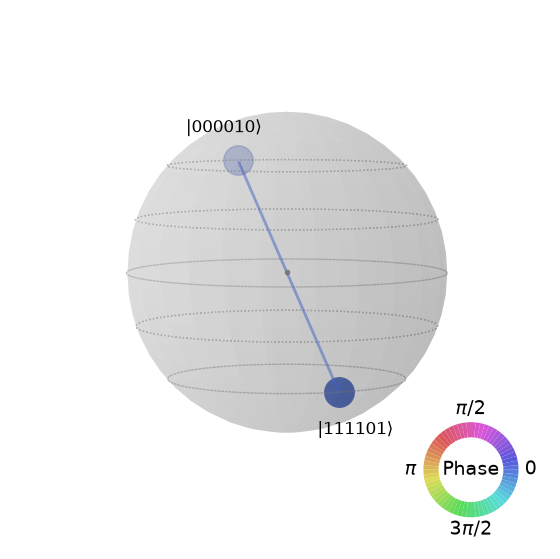

In [6]:
plot_state_qsphere(sv, show_state_labels=True)

Because you built the same circuit shown in Chapter 2, your final Statevector should pass Exercise 4 in the grader if the circuit was assembled correctly.
If you don't pass, don't be surprised! Many of you have already passed the grader earlier, so even if you get it wrong this time, your final Progress Check result will not change. Please remember this is an __optional__ exercise.

In [11]:
grade_lab0_ex4(sv)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. Fidelity: 1.000000
You just created the Qiskit logo!

Looking forward to the QGSS main event starting in a week? Take this course:
https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today
You scored 1 on this exercise.


In [12]:
check_progress("lab0")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0


# Additional information

**Created by:** Sophy Shin

**Version:** 1.0.0